**EcoReward – Waste Image Classification (MVP)**

This notebook trains a simple image classification model to identify waste types
(plastic, paper, metal, glass, organic, electronic, unsorted) for EcoReward’s
AI-assisted waste verification system.

The goal is **demonstration and validation**, not high-accuracy production AI.

**DATA PREPARATION**

In [6]:
#1 mount google drive to access the EcoReward dataset stored

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#2 define dataset directory paths that points to the training and validation image folders

import os

base_dir = "/content/drive/MyDrive/Machine_Learning_Journey/EcoReward_Dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "validation")

In [8]:
#3a chaeck how many images exist per class to understand class imbalance and confirms data loading (Training Images)

for class_name in os.listdir(train_dir):
  class_path = os.path.join(train_dir, class_name)
  print(f"{class_name}: {len(os.listdir(class_path))} training images")

plastic: 80 training images
paper: 80 training images
metal: 80 training images
glass: 80 training images


In [9]:
#3b chaeck how many images exist per class to understand class imbalance and confirms data loading (Validation Images)

for class_name in os.listdir(val_dir):
  class_path = os.path.join(val_dir, class_name)
  print(f"{class_name}: {len(os.listdir(class_path))} validation images")

plastic: 20 validation images
paper: 20 validation images
glass: 20 validation images
metal: 20 validation images


In [10]:
#4 import required lbraries
# TensorFlow/Keras handles the deep learning
# Matplotlib is used for visualization
# Numpy supports numerical operations

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

**DATA GENERATORS**

In [11]:
#5 create image data generators to handle image loading, resizing, normalization, and augmentation

img_size = (224, 224)
batch_size = 16

train_generator = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_generator = ImageDataGenerator(
    rescale=1.0/255
)

In [12]:
#6a load images from directories
# keras assigns labels based on folder names

train_data = train_generator.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_data = validation_generator.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

Found 311 images belonging to 4 classes.
Found 75 images belonging to 4 classes.


In [13]:
#6b create validation data generator
# validation data should NOT be augmented

val_datagen = ImageDataGenerator(
    rescale=1./255
)

# load validation images from directory

val_generator = val_datagen.flow_from_directory(
    val_dir,                                              # Path to validation data
    target_size=(224, 224),                               # Image size expected by the model
    batch_size=32,
    class_mode='categorical'                              # Multi-class classification
)

Found 75 images belonging to 4 classes.


**BASE MODEL LOADING**

In [14]:
#7 load MobileNetV2 as the base model (pre-trained on ImageNet)
# this exclude the top layers because we will add our own classifier

from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**FREEZING LAYERS**

In [15]:
#8 freeze all layers in the base model so they are not trained

base_model.trainable = False

**MODEL ARCHITECTURE SETUP**

In [16]:
#9 build the full model by adding a custom classification head

from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,                                   # Feature extractor
    layers.GlobalAveragePooling2D(),              # Reduce feature maps
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),                          # Prevents overfitting
    layers.Dense(4, activation='softmax')         # 4 waste classes
])

**MODEL COMPILATION**

In [17]:
#10 compile the model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**MODEL SUMMARY**

In [18]:
#11 summarize model structure so far

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**MODEL TRAINING**

In [20]:
#12 train the model on the training dataset
# validation data is used to monitor performance on unseen data

history = model.fit(
    train_data,                      # Training data generator
    validation_data=val_data,        # Validation data generator
    epochs=10
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.9775 - loss: 0.0673 - val_accuracy: 0.8133 - val_loss: 0.6144
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.9657 - loss: 0.0850 - val_accuracy: 0.7867 - val_loss: 0.7305
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.9898 - loss: 0.0592 - val_accuracy: 0.7733 - val_loss: 0.6415
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9730 - loss: 0.0664 - val_accuracy: 0.7600 - val_loss: 0.6763
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9928 - loss: 0.0457 - val_accuracy: 0.7200 - val_loss: 0.9167
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9925 - loss: 0.0378 - val_accuracy: 0.7467 - val_loss: 0.7900
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.9971 - loss: 0.0234 - val_accuracy: 0.7200 - val_loss: 0.8961
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.9861 - loss: 0.0368 - val_accuracy: 0.7467 - val_loss:

In [21]:
#13 view history values

history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

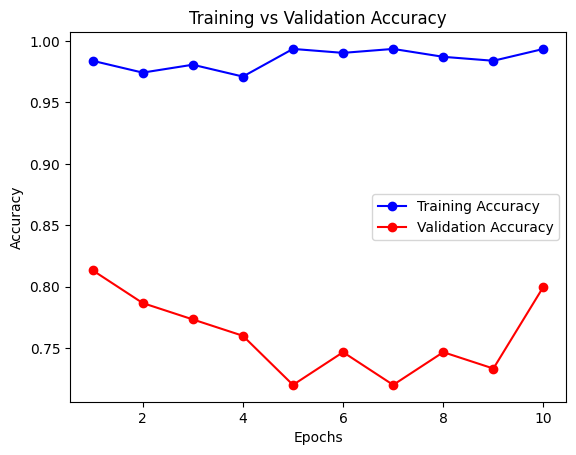

In [22]:
#14 plot training vs validation accuracy

import matplotlib.pyplot as plt

# extract accuracy values from training history

train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# create a list of epoch numbers

epochs = range(1, len(train_accuracy) + 1)

# plot training and validation accuracy

plt.plot(epochs, train_accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'ro-', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [23]:
#15 save trained model in keras native format for later use

model.save("waste_classifier_v2.keras")

In [24]:
#16 import load_model to reload a saved keras model

from tensorflow.keras.models import load_model

# load the previously saved trained model

model = load_model("waste_classifier_v2.keras")

In [71]:
#17 evaluate the model performance on the validation dataset

model.evaluate(val_generator)

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8102 - loss: 0.5984


[0.6555041670799255, 0.800000011920929]

In [72]:
#18 load and preprocess a single image for prediction (glass)

from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/drive/MyDrive/Machine_Learning_Journey/EcoReward_Test_Dataset/glass/download.jpg"
img = image.load_img(
    img_path,
    target_size=(224, 224)      # use the same size you trained with
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [73]:
# run the trained model on the inpute image to get prediction probabilities

prediction = model.predict(img_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
[[9.3453962e-01 5.8231552e-05 1.2457848e-02 5.2944236e-02]]


In [74]:
# get the index of the class with the highest prediction probability

predicted_class = np.argmax(prediction, axis=1)
confidence = np.max(prediction)

In [75]:
# display the predicted class index & confidence score

print("Predicted class index:", predicted_class[0])
print("Confidence:", confidence)

Predicted class index: 0
Confidence: 0.9345396


In [36]:
# retrieve the mapping of class names to numerical indicies

class_indices = val_generator.class_indices

# convert class indicies back to human-readable class labels

reversed_class_labels = {v: k for k, v in class_indices.items()}

# display the predicted waste category

print("Predicted label:", reversed_class_labels[predicted_class[0]])

Predicted label: glass


In [37]:
#19 load and preprocess a single image for prediction (metal)

img_path = "/content/drive/MyDrive/Machine_Learning_Journey/EcoReward_Test_Dataset/metal/SCRAP COMPRESSORS.jpg"
img = image.load_img(
    img_path,
    target_size=(224, 224)      # use the same size you trained with
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [38]:
# run the trained model on the inpute image to get prediction probeailities

prediction2 = model.predict(img_array)
print(prediction2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
[[1.2066721e-04 9.9977607e-01 6.9265203e-05 3.4133849e-05]]


In [39]:
# get the index of the class with the highest prediction probability

predicted_class = np.argmax(prediction2, axis=1)
confidence = np.max(prediction2)

In [40]:
# display the predicted class index & confidence score

print("Predicted class index:", predicted_class[0])
print("Confidence:", confidence)

Predicted class index: 1
Confidence: 0.99977607


In [42]:
# retrieve the mapping of class names to numerical indicies

class_indices = val_generator.class_indices

# convert class indicies back to human-readable class labels

reversed_class_labels = {v: k for k, v in class_indices.items()}

# display the predicted waste category

print("Predicted label:", reversed_class_labels[predicted_class[0]])

Predicted label: metal


In [47]:
#20 load and preprocess a single image for prediction (paper)

img_path = "/content/drive/MyDrive/Machine_Learning_Journey/EcoReward_Test_Dataset/paper/Metallic Print Color Wrapping Paper Translucent Wrapping Paper Tissue Paper Craft Paper Gift Wrapping Tissue Paper Bulk For Art Craft Floral Birthday Party Festival Gift Wrap Art Crafts Diy Pack Bags 20x14 20 Sheets .jpg"
img = image.load_img(
    img_path,
    target_size=(224, 224)      # use the same size you trained with
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [48]:
# run the trained model on the inpute image to get prediction probabilities

prediction3 = model.predict(img_array)
print(prediction3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
[[0.00265733 0.00436998 0.99197716 0.00099554]]


In [49]:
# get the index of the class with the highest prediction probability

predicted_class = np.argmax(prediction3, axis=1)
confidence = np.max(prediction3)

In [50]:
# display the predicted class index & confidence score

print("Predicted class index:", predicted_class[0])
print("Confidence:", confidence)

Predicted class index: 2
Confidence: 0.99197716


In [51]:
# retrieve the mapping of class names to numerical indicies

class_indices = val_generator.class_indices

# convert class indicies back to human-readable class labels

reversed_class_labels = {v: k for k, v in class_indices.items()}

# display the predicted waste category

print("Predicted label:", reversed_class_labels[predicted_class[0]])

Predicted label: paper


In [64]:
#21 load and preprocess a single image for prediction (plastic)

img_path = "/content/drive/MyDrive/Machine_Learning_Journey/EcoReward_Test_Dataset/plastic/For a Healthier Trip, Avoid This Common Mistake _ Porthole Cruise.jpg"
img = image.load_img(
    img_path,
    target_size=(224, 224)      # use the same size you trained with
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [65]:
# run the trained model on the inpute image to get prediction probabilities

prediction4 = model.predict(img_array)
print(prediction4)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
[[1.8597306e-05 6.1752580e-05 4.4843944e-04 9.9947125e-01]]


In [66]:
# get the index of the class with the highest prediction probability

predicted_class = np.argmax(prediction4, axis=1)
confidence = np.max(prediction4)

In [67]:
# display the predicted class index & confidence score

print("Predicted class index:", predicted_class[0])
print("Confidence:", confidence)

Predicted class index: 3
Confidence: 0.99947125


In [68]:
# retrieve the mapping of class names to numerical indicies

class_indices = val_generator.class_indices

# convert class indicies back to human-readable class labels

reversed_class_labels = {v: k for k, v in class_indices.items()}

# display the predicted waste category

print("Predicted label:", reversed_class_labels[predicted_class[0]])

Predicted label: plastic


In [69]:
# download model from google colab

from google.colab import files

files.download('waste_classifier_v2.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>